# Trajectory-block distance-distribution statistics

This workflow quantifies differences between **already calculated** structural-distance
distributions. It never reads structural coordinates and never recalculates a distance.

Retained recycle snapshots from one AlphaFold seed/model trajectory are correlated, so CSV rows are
not treated as independent replicates. The independent block is `(seed, model_number)`. The primary
effect size is the trajectory-balanced 1-Wasserstein distance (W1), expressed in Å: it is the average
distance that probability mass must move to transform one distribution into the other. Each
trajectory receives equal total weight even when it retained more recycle snapshots.

W1 is unsigned. Median shift supplies direction, while `log2(IQR_B/IQR_A)` describes broadening
(positive) or narrowing (negative). Permutations swap complete paired trajectories and bootstraps
resample complete trajectory pairs; recycle rows are never independently shuffled or resampled.

## 1. Configuration

Use exploratory mode while developing; publication mode increases Monte Carlo precision.

In [1]:
from pathlib import Path
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
from shared.distribution_statistics import (
    adjust_fdr, analyze_distance, cache_key, candidate_distance_columns,
    dataset_audit, distribution_metrics, exact_common_distance_columns,
    paired_block_bootstrap, paired_block_permutation, parse_trajectory_metadata,
    pairing_audit, stable_seed, trajectory_weights, unmatched_distance_columns,
)
import shared.distribution_statistics as dstats
from shared.plotting import CAV12_PALETTE, KV21_PALETTE, NAV15_PALETTE

PROJECT_COLORS = {
    'cav12': {'light': CAV12_PALETTE['WT_VAN'], 'dark': CAV12_PALETTE['WT_HM']},
    'kv21': {'light': KV21_PALETTE['WT_VAN'], 'dark': KV21_PALETTE['WT_HM']},
    'nav15': {'light': NAV15_PALETTE['WT_VAN'], 'dark': NAV15_PALETTE['WT_MASKED_V2']},
}
PROJECT_CMAPS = {channel: LinearSegmentedColormap.from_list(f'{channel}_statistics', ['#FFFFFF', colors['light'], colors['dark']]) for channel, colors in PROJECT_COLORS.items()}

RANDOM_SEED = 20260816
RUN_MODE = 'exploratory'  # 'exploratory' or 'publication'
RUN_SETTINGS = {
    'exploratory': {'n_permutations': 999, 'n_bootstrap': 500},
    'publication': {'n_permutations': 9999, 'n_bootstrap': 2000},
}
if RUN_MODE not in RUN_SETTINGS:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')
N_PERMUTATIONS = RUN_SETTINGS[RUN_MODE]['n_permutations']
N_BOOTSTRAP = RUN_SETTINGS[RUN_MODE]['n_bootstrap']

# Optional execution-check limit. Smoke results use a separate directory and are not publication results.
SMOKE_MAX_DISTANCES = int(os.environ.get('DISTANCE_STATS_SMOKE_MAX_DISTANCES', '0')) or None
if SMOKE_MAX_DISTANCES:
    # Execution validation only; normal exploratory mode retains 999/500 above.
    N_PERMUTATIONS = min(N_PERMUTATIONS, 99)
    N_BOOTSTRAP = min(N_BOOTSTRAP, 50)
output_root = repo_root / 'notebooks/statistics/outputs'
if SMOKE_MAX_DISTANCES:
    output_root = output_root / 'smoke'
figure_dir = output_root / 'figures'
cache_dir = output_root / 'cache'
figure_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)
print({'run_mode': RUN_MODE, 'permutations': N_PERMUTATIONS, 'bootstrap': N_BOOTSTRAP,
       'smoke_max_distances': SMOKE_MAX_DISTANCES, 'output_root': str(output_root.relative_to(repo_root))})

{'run_mode': 'exploratory', 'permutations': 999, 'bootstrap': 500, 'smoke_max_distances': None, 'output_root': 'notebooks/statistics/outputs'}


## 2. Dataset registry

Paths mirror the current publication-facing channel notebooks. Loading is strict: a missing final-QC file raises rather than falling back to `all`.

In [2]:
data_cav = repo_root / 'cav12/dataDistances'
data_kv = repo_root / 'kv21/dataDistances'
data_nav = repo_root / 'nav15/dataDistances'

dataset_rows = [
 ('cav12','WT','vanilla',data_cav/'26-02-10_Cav12_wt_vanillaAF2_distances_all.csv','all_ok_3'),
 ('cav12','WT','masked',data_cav/'26-02-10_Cav12_wt_maskedAF2_distances_all.csv','all_ok_3'),
 ('cav12','G402S','vanilla',data_cav/'26-02-10_Cav12_g402s_vanillaAF2_distances_all.csv','all_ok_3'),
 ('cav12','G402S','masked',data_cav/'26-02-10_Cav12_g402s_maskedAF2_distances_all.csv','all_ok_3'),
 ('cav12','G406R','vanilla',data_cav/'26-07-25_Cav1.2_g406r_vanillaAF2_distances_all.csv','all_ok_3'),
 ('cav12','G406R','masked',data_cav/'26-07-25_Cav1.2_g406r_maskedAF2_distances_all.csv','all_ok_3'),
 ('kv21','WT','vanilla',data_kv/'26-02-11_Kv2.1_wt_vanillaAF2_distances_all.csv','all_ok_3_structural_interface_alignment_qc'),
 ('kv21','WT','masked',data_kv/'26-02-11_Kv2.1_wt_maskedAF2_distances_all.csv','all_ok_3_structural_interface_alignment_qc'),
 ('kv21','L403A','vanilla',data_kv/'26-02-11_Kv2.1_l403a_vanillaAF2_distances_all.csv','all_ok_3_structural_interface_alignment_qc'),
 ('kv21','L403A','masked',data_kv/'26-02-11_Kv2.1_l403a_maskedAF2_distances_all.csv','all_ok_3_structural_interface_alignment_qc'),
 ('kv21','F412L','vanilla',data_kv/'26-02-11_Kv2.1_f412l_vanillaAF2_distances_all.csv','all_ok_3_structural_interface_alignment_qc'),
 ('kv21','F412L','masked',data_kv/'26-02-11_Kv2.1_f412l_maskedAF2_distances_all.csv','all_ok_3_structural_interface_alignment_qc'),
 ('nav15','WT','vanilla',data_nav/'26-07-27_Nav15_wt_vanillaAF2_distances_all_all.csv','all_ok_3'),
 ('nav15','WT','masked_v2',data_nav/'26-07-27_Nav15_wt_maskedv2_AF2_distances_all_all.csv','all_ok_3'),
 ('nav15','WT','masked_v2_noIFM',data_nav/'26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances_all_all.csv','all_ok_3'),
 ('nav15','QQQ','vanilla',data_nav/'26-07-27_Nav15_qqq_vanilla_AF2_distances_all_all.csv','all_ok_3'),
 ('nav15','QQQ','masked',data_nav/'26-07-27_Nav15_qqq_masked_AF2_distances_all_all.csv','all_ok_3'),
 ('nav15','QQQ','masked_v2',data_nav/'26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_all.csv','all_ok_3'),
]
dataset_registry = pd.DataFrame(dataset_rows, columns=['channel','condition','protocol','original_path','requested_dataset'])
dataset_registry['original_path'] = dataset_registry['original_path'].map(lambda path: Path(path).relative_to(repo_root))
dataset_registry['ensemble_id'] = dataset_registry[['channel','condition','protocol']].agg('|'.join, axis=1)
dataset_registry

,channel,condition,protocol,original_path,requested_dataset,ensemble_id
0,cav12,WT,vanilla,cav12/dataDistances/26-02-10_Cav12_wt_vanillaA...,all_ok_3,cav12|WT|vanilla
1,cav12,WT,masked,cav12/dataDistances/26-02-10_Cav12_wt_maskedAF...,all_ok_3,cav12|WT|masked
2,cav12,G402S,vanilla,cav12/dataDistances/26-02-10_Cav12_g402s_vanil...,all_ok_3,cav12|G402S|vanilla
3,cav12,G402S,masked,cav12/dataDistances/26-02-10_Cav12_g402s_maske...,all_ok_3,cav12|G402S|masked
4,cav12,G406R,vanilla,cav12/dataDistances/26-07-25_Cav1.2_g406r_vani...,all_ok_3,cav12|G406R|vanilla
5,cav12,G406R,masked,cav12/dataDistances/26-07-25_Cav1.2_g406r_mask...,all_ok_3,cav12|G406R|masked
6,kv21,WT,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,all_ok_3_structural_interface_alignment_qc,kv21|WT|vanilla
7,kv21,WT,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,all_ok_3_structural_interface_alignment_qc,kv21|WT|masked
8,kv21,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,kv21|L403A|vanilla
9,kv21,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,all_ok_3_structural_interface_alignment_qc,kv21|L403A|masked


In [3]:
from contextlib import redirect_stdout
from io import StringIO

def load_registry_row(row):
    options = distance_csv_options(repo_root, row.original_path, row.channel, row.condition, row.protocol)
    with redirect_stdout(StringIO()):
        return load_selected_distance_csv(row.ensemble_id, options, row.requested_dataset, fallback_to_all=False)

frames = {}
audits = []
for row in dataset_registry.itertuples(index=False):
    loaded = load_registry_row(row)
    # Persist portable repository-relative provenance, never workstation paths.
    source = Path(loaded.attrs['source_path']).resolve()
    loaded.attrs['source_path'] = str(source.relative_to(repo_root.resolve()))
    parsed = parse_trajectory_metadata(loaded)
    frames[row.ensemble_id] = parsed
    audits.append(dataset_audit(loaded, channel=row.channel, condition=row.condition,
                                protocol=row.protocol, requested_dataset=row.requested_dataset))
dataset_audit_table = pd.DataFrame(audits)
dataset_audit_table.to_csv(output_root / 'dataset_audit.csv', index=False)
dataset_audit_table

,channel,condition,protocol,requested_dataset,actual_dataset,source_path,n_rows,n_distance_columns,n_trajectories,min_rows_per_trajectory,median_rows_per_trajectory,max_rows_per_trajectory,trajectory_parse_failures,duplicate_pdb_file_count
0,cav12,WT,vanilla,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_wt_vanillaA...,5000,694,500,10,10.0,10,0,0
1,cav12,WT,masked,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_wt_maskedAF...,4996,694,500,9,10.0,10,0,0
2,cav12,G402S,vanilla,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_g402s_vanil...,5000,700,500,10,10.0,10,0,0
3,cav12,G402S,masked,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_g402s_maske...,4995,700,500,9,10.0,10,0,0
4,cav12,G406R,vanilla,all_ok_3,all_ok_3,cav12/dataDistances/26-07-25_Cav1.2_g406r_vani...,5000,698,500,10,10.0,10,0,0
5,cav12,G406R,masked,all_ok_3,all_ok_3,cav12/dataDistances/26-07-25_Cav1.2_g406r_mask...,4997,698,500,9,10.0,10,0,0
6,kv21,WT,vanilla,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,4562,1074,487,1,9.0,10,0,0
7,kv21,WT,masked,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,3658,1410,419,2,9.0,10,0,0
8,kv21,L403A,vanilla,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,4371,1410,479,1,9.0,10,0,0
9,kv21,L403A,masked,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,3693,1410,426,3,9.0,10,0,0


## 3. Dataset and trajectory QC

Inspect this table before expensive inference. It exposes the actual selector, source, parse status, duplicates, and retained rows per trajectory.

,channel,condition,protocol,requested_dataset,actual_dataset,source_path,n_rows,n_distance_columns,n_trajectories,min_rows_per_trajectory,median_rows_per_trajectory,max_rows_per_trajectory,trajectory_parse_failures,duplicate_pdb_file_count
0,cav12,WT,vanilla,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_wt_vanillaA...,5000,694,500,10,10.0,10,0,0
1,cav12,WT,masked,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_wt_maskedAF...,4996,694,500,9,10.0,10,0,0
2,cav12,G402S,vanilla,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_g402s_vanil...,5000,700,500,10,10.0,10,0,0
3,cav12,G402S,masked,all_ok_3,all_ok_3,cav12/dataDistances/26-02-10_Cav12_g402s_maske...,4995,700,500,9,10.0,10,0,0
4,cav12,G406R,vanilla,all_ok_3,all_ok_3,cav12/dataDistances/26-07-25_Cav1.2_g406r_vani...,5000,698,500,10,10.0,10,0,0
5,cav12,G406R,masked,all_ok_3,all_ok_3,cav12/dataDistances/26-07-25_Cav1.2_g406r_mask...,4997,698,500,9,10.0,10,0,0
6,kv21,WT,vanilla,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,4562,1074,487,1,9.0,10,0,0
7,kv21,WT,masked,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,3658,1410,419,2,9.0,10,0,0
8,kv21,L403A,vanilla,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,4371,1410,479,1,9.0,10,0,0
9,kv21,L403A,masked,all_ok_3_structural_interface_alignment_qc,all_ok_3_structural_interface_alignment_qc,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,3693,1410,426,3,9.0,10,0,0


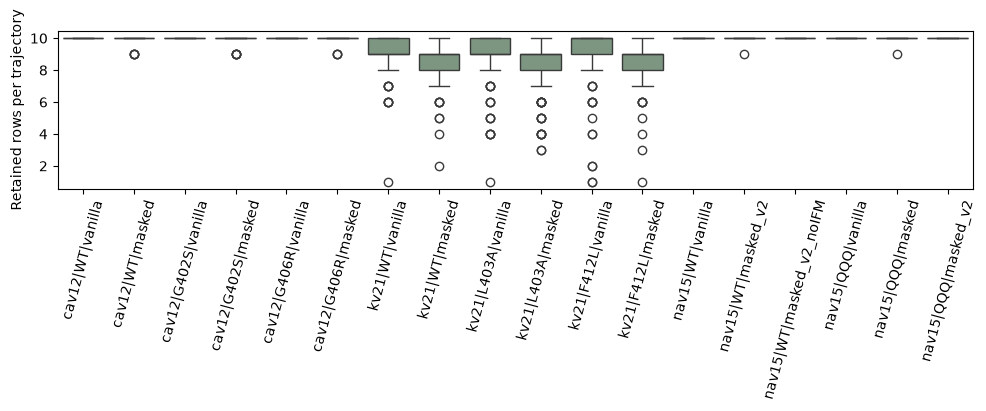

In [4]:
assert (dataset_audit_table['requested_dataset'] == dataset_audit_table['actual_dataset']).all()
assert dataset_audit_table['trajectory_parse_failures'].eq(0).all()
display(dataset_audit_table)

fig, ax = plt.subplots(figsize=(10, 4))
counts = pd.concat([
    f.groupby('trajectory_id').size().rename('retained_rows').to_frame().assign(ensemble_id=k)
    for k, f in frames.items()
]).reset_index(drop=True)
count_palette = {ensemble: PROJECT_COLORS[ensemble.split('|')[0]]['dark'] for ensemble in counts.ensemble_id.unique()}
sns.boxplot(data=counts, x='ensemble_id', y='retained_rows', hue='ensemble_id', palette=count_palette, legend=False, ax=ax)
ax.tick_params(axis='x', rotation=75); ax.set_ylabel('Retained rows per trajectory'); ax.set_xlabel('')
fig.tight_layout(); display(fig); plt.close(fig)

## 4. Explicit biological comparisons

No uncontrolled all-versus-all matrix is generated. WT–mutant comparisons use exact common column names only; unmatched names are audited rather than canonicalized.

In [5]:
comparison_rows = [
 ('cav_wt_mask','cav12','WT','vanilla','WT','masked','masking',True,'primary',''),
 ('cav_g402s_mask','cav12','G402S','vanilla','G402S','masked','masking',True,'primary',''),
 ('cav_g406r_mask','cav12','G406R','vanilla','G406R','masked','masking',True,'primary',''),
 ('cav_wt_g402s_van','cav12','WT','vanilla','G402S','vanilla','mutation',True,'primary','exact names only'),
 ('cav_wt_g402s_mask','cav12','WT','masked','G402S','masked','mutation',True,'primary','exact names only'),
 ('cav_wtvan_g402smask','cav12','WT','vanilla','G402S','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('cav_wtmask_g402svan','cav12','WT','masked','G402S','vanilla','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('cav_wt_g406r_van','cav12','WT','vanilla','G406R','vanilla','mutation',True,'primary','exact names only'),
 ('cav_wt_g406r_mask','cav12','WT','masked','G406R','masked','mutation',True,'primary','exact names only'),
 ('cav_wtvan_g406rmask','cav12','WT','vanilla','G406R','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('cav_wtmask_g406rvan','cav12','WT','masked','G406R','vanilla','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('kv_wt_mask','kv21','WT','vanilla','WT','masked','masking',True,'primary',''),
 ('kv_l403a_mask','kv21','L403A','vanilla','L403A','masked','masking',True,'primary',''),
 ('kv_f412l_mask','kv21','F412L','vanilla','F412L','masked','masking',True,'primary',''),
 ('kv_wt_l403a_van','kv21','WT','vanilla','L403A','vanilla','mutation',True,'primary','exact names only'),
 ('kv_wt_l403a_mask','kv21','WT','masked','L403A','masked','mutation',True,'primary','exact names only'),
 ('kv_wtvan_l403amask','kv21','WT','vanilla','L403A','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('kv_wtmask_l403avan','kv21','WT','masked','L403A','vanilla','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('kv_wt_f412l_van','kv21','WT','vanilla','F412L','vanilla','mutation',True,'primary','exact names only'),
 ('kv_wt_f412l_mask','kv21','WT','masked','F412L','masked','mutation',True,'primary','exact names only'),
 ('kv_wtvan_f412lmask','kv21','WT','vanilla','F412L','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('kv_wtmask_f412lvan','kv21','WT','masked','F412L','vanilla','mutation_cross_protocol',True,'sensitivity','non-equivalent protocols'),
 ('nav_wt_van_maskv2','nav15','WT','vanilla','WT','masked_v2','masking',True,'primary',''),
 ('nav_wt_van_noifm','nav15','WT','vanilla','WT','masked_v2_noIFM','mask_sensitivity',True,'primary',''),
 ('nav_wt_maskv2_noifm','nav15','WT','masked_v2','WT','masked_v2_noIFM','mask_sensitivity',True,'primary',''),
 ('nav_qqq_van_mask','nav15','QQQ','vanilla','QQQ','masked','masking',True,'primary',''),
 ('nav_qqq_van_maskv2','nav15','QQQ','vanilla','QQQ','masked_v2','masking',True,'primary',''),
 ('nav_qqq_mask_maskv2','nav15','QQQ','masked','QQQ','masked_v2','mask_sensitivity',True,'primary',''),
 ('nav_wt_qqq_van','nav15','WT','vanilla','QQQ','vanilla','mutation',True,'primary','like-for-like'),
 ('nav_wt_qqq_maskv2','nav15','WT','masked_v2','QQQ','masked_v2','mutation',True,'primary','like-for-like v2'),
 ('nav_wtvan_qqqmask','nav15','WT','vanilla','QQQ','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent masks'),
 ('nav_wtvan_qqqmaskv2','nav15','WT','vanilla','QQQ','masked_v2','mutation_cross_protocol',True,'sensitivity','cross-protocol v2'),
 ('nav_wtmaskv2_qqqvan','nav15','WT','masked_v2','QQQ','vanilla','mutation_cross_protocol',True,'sensitivity','cross-protocol v2'),
 ('nav_wtmaskv2_qqqmask','nav15','WT','masked_v2','QQQ','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent masks'),
 ('nav_wtnoifm_qqqvan','nav15','WT','masked_v2_noIFM','QQQ','vanilla','mutation_cross_protocol',True,'sensitivity','non-equivalent masks'),
 ('nav_wtnoifm_qqqmask','nav15','WT','masked_v2_noIFM','QQQ','masked','mutation_cross_protocol',True,'sensitivity','non-equivalent masks'),
 ('nav_wtnoifm_qqqmaskv2','nav15','WT','masked_v2_noIFM','QQQ','masked_v2','mutation_cross_protocol',True,'sensitivity','non-equivalent masks'),
]
comparison_registry = pd.DataFrame(comparison_rows, columns=[
 'comparison_id','channel','condition_A','protocol_A','condition_B','protocol_B',
 'comparison_class','paired_expected','primary_or_sensitivity','notes'])
comparison_registry

,comparison_id,channel,condition_A,protocol_A,condition_B,protocol_B,comparison_class,paired_expected,primary_or_sensitivity,notes
0,cav_wt_mask,cav12,WT,vanilla,WT,masked,masking,True,primary,
1,cav_g402s_mask,cav12,G402S,vanilla,G402S,masked,masking,True,primary,
2,cav_g406r_mask,cav12,G406R,vanilla,G406R,masked,masking,True,primary,
3,cav_wt_g402s_van,cav12,WT,vanilla,G402S,vanilla,mutation,True,primary,exact names only
4,cav_wt_g402s_mask,cav12,WT,masked,G402S,masked,mutation,True,primary,exact names only
5,cav_wtvan_g402smask,cav12,WT,vanilla,G402S,masked,mutation_cross_protocol,True,sensitivity,non-equivalent protocols
6,cav_wtmask_g402svan,cav12,WT,masked,G402S,vanilla,mutation_cross_protocol,True,sensitivity,non-equivalent protocols
7,cav_wt_g406r_van,cav12,WT,vanilla,G406R,vanilla,mutation,True,primary,exact names only
8,cav_wt_g406r_mask,cav12,WT,masked,G406R,masked,mutation,True,primary,exact names only
9,cav_wtvan_g406rmask,cav12,WT,vanilla,G406R,masked,mutation_cross_protocol,True,sensitivity,non-equivalent protocols


In [6]:
pairing_rows, unmatched_tables = [], []
for row in comparison_registry.itertuples(index=False):
    a = frames[f'{row.channel}|{row.condition_A}|{row.protocol_A}']
    b = frames[f'{row.channel}|{row.condition_B}|{row.protocol_B}']
    audit = pairing_audit(dict.fromkeys(a.trajectory_id), dict.fromkeys(b.trajectory_id))
    pairing_rows.append({'comparison_id': row.comparison_id, **audit})
    unmatched = unmatched_distance_columns(a, b).dropna(how='all')
    if not unmatched.empty:
        unmatched.insert(0, 'comparison_id', row.comparison_id)
        unmatched_tables.append(unmatched)
pairing_audit_table = pd.DataFrame(pairing_rows)
pairing_audit_table['pairing_warning'] = pairing_audit_table[['fraction_A_matched','fraction_B_matched']].min(axis=1) < .8
pairing_audit_table.to_csv(output_root / 'pairing_audit.csv', index=False)
unmatched_audit = pd.concat(unmatched_tables, ignore_index=True) if unmatched_tables else pd.DataFrame()
unmatched_audit.to_csv(output_root / 'unmatched_distance_columns.csv', index=False)
display(pairing_audit_table)
if pairing_audit_table.pairing_warning.any():
    warnings.warn('PROMINENT PAIRING WARNING: one or more comparisons have <80% trajectory coverage. See pairing_audit.csv')

,comparison_id,n_trajectories_A,n_trajectories_B,n_matched_trajectories,fraction_A_matched,fraction_B_matched,pairing_warning
0,cav_wt_mask,500,500,500,1.000000,1.000000,False
1,cav_g402s_mask,500,500,500,1.000000,1.000000,False
2,cav_g406r_mask,500,500,500,1.000000,1.000000,False
3,cav_wt_g402s_van,500,500,500,1.000000,1.000000,False
4,cav_wt_g402s_mask,500,500,500,1.000000,1.000000,False
5,cav_wtvan_g402smask,500,500,500,1.000000,1.000000,False
6,cav_wtmask_g402svan,500,500,500,1.000000,1.000000,False
7,cav_wt_g406r_van,500,500,500,1.000000,1.000000,False
8,cav_wt_g406r_mask,500,500,500,1.000000,1.000000,False
9,cav_wtvan_g406rmask,500,500,500,1.000000,1.000000,False


/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_92194/2935327658.py:18: UserWarning: PROMINENT PAIRING WARNING: one or more comparisons have <80% trajectory coverage. See pairing_audit.csv
  warnings.warn('PROMINENT PAIRING WARNING: one or more comparisons have <80% trajectory coverage. See pairing_audit.csv')


## 5. Worked example

The cells below expose parsing, per-row weights, the permutation null, and the block-bootstrap distribution before applying the machinery broadly.

In [7]:
EXAMPLE_COMPARISON = 'cav_wt_mask'
example_spec = comparison_registry.set_index('comparison_id').loc[EXAMPLE_COMPARISON]
example_a = frames[f"{example_spec.channel}|{example_spec.condition_A}|{example_spec.protocol_A}"]
example_b = frames[f"{example_spec.channel}|{example_spec.condition_B}|{example_spec.protocol_B}"]
EXAMPLE_DISTANCE = exact_common_distance_columns(example_a, example_b)[0]
display(example_a[['pdb_file','seed','model_number','recycle_number','trajectory_id',EXAMPLE_DISTANCE]].head(12))
example_weights = trajectory_weights(example_a, EXAMPLE_DISTANCE)
display(pd.DataFrame({'trajectory_id': example_a.loc[example_weights.index,'trajectory_id'],
                      'value_A': pd.to_numeric(example_a.loc[example_weights.index,EXAMPLE_DISTANCE]),
                      'weight': example_weights}).head(20))

ba, bb = dstats._blocks(example_a, EXAMPLE_DISTANCE), dstats._blocks(example_b, EXAMPLE_DISTANCE)
keys = sorted(set(ba) & set(bb))
example_metrics = distribution_metrics([ba[k] for k in keys], [bb[k] for k in keys])
p_example, null_example = paired_block_permutation(
    ba, bb, n_permutations=N_PERMUTATIONS, random_seed=RANDOM_SEED, return_null=True)
ci_example, boot_example = paired_block_bootstrap(
    ba, bb, n_bootstrap=N_BOOTSTRAP, random_seed=RANDOM_SEED+1, return_samples=True)
display(pd.DataFrame([{**example_metrics, **ci_example, 'p_W1_permutation': p_example}]))

,pdb_file,seed,model_number,recycle_number,trajectory_id,CA_ARG1018_CA-ASP899_CA
0,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,1,"(159, 3)",30.50
1,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,10,"(159, 3)",30.20
2,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,2,"(159, 3)",30.91
3,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,3,"(159, 3)",30.59
4,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,4,"(159, 3)",30.52
5,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,5,"(159, 3)",30.40
6,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,6,"(159, 3)",30.44
7,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,7,"(159, 3)",30.37
8,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,8,"(159, 3)",30.63
9,cav12_wt_short_unrelaxed_rank_001_alphafold2_p...,159,3,9,"(159, 3)",30.27


,trajectory_id,value_A,weight
0,"(159, 3)",30.50,0.0002
1,"(159, 3)",30.20,0.0002
2,"(159, 3)",30.91,0.0002
3,"(159, 3)",30.59,0.0002
4,"(159, 3)",30.52,0.0002
5,"(159, 3)",30.40,0.0002
6,"(159, 3)",30.44,0.0002
7,"(159, 3)",30.37,0.0002
8,"(159, 3)",30.63,0.0002
9,"(159, 3)",30.27,0.0002


,median_A_A,median_B_A,delta_median_A,IQR_A_A,IQR_B_A,IQR_ratio_B_over_A,log2_IQR_ratio,IQR_A_effectively_zero,IQR_B_effectively_zero,W1_A,pooled_IQR_A,W1_normalized_by_pooled_IQR,KS_D,W1_CI_low_A,W1_CI_high_A,delta_median_CI_low_A,delta_median_CI_high_A,log2_IQR_ratio_CI_low,log2_IQR_ratio_CI_high,p_W1_permutation
0,30.4,29.83,-0.57,0.35,0.58,1.657143,0.728698,False,False,0.575569,0.6,0.959282,0.62231,0.55533,0.596311,-0.6,-0.53,0.584963,0.824913,0.001


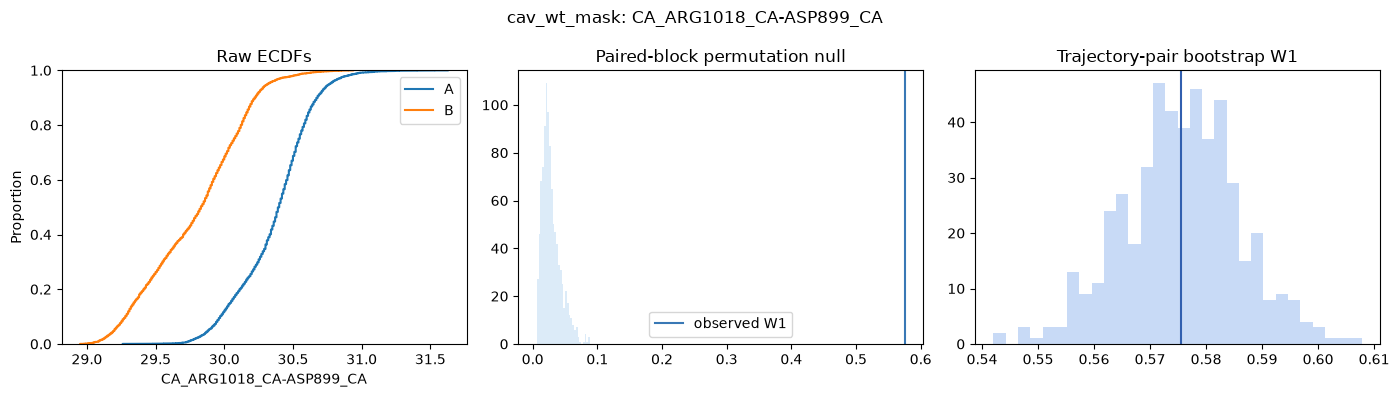

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.ecdfplot(x=pd.to_numeric(example_a[EXAMPLE_DISTANCE], errors='coerce'), label='A', ax=axes[0])
sns.ecdfplot(x=pd.to_numeric(example_b[EXAMPLE_DISTANCE], errors='coerce'), label='B', ax=axes[0]); axes[0].legend(); axes[0].set_title('Raw ECDFs')
axes[1].hist(null_example, bins=30, color=CAV12_PALETTE['WT_VAN']); axes[1].axvline(example_metrics['W1_A'], color=CAV12_PALETTE['WT_HM'], label='observed W1'); axes[1].legend(); axes[1].set_title('Paired-block permutation null')
axes[2].hist(boot_example[:,0], bins=30, color=CAV12_PALETTE['G402S_VAN']); axes[2].axvline(example_metrics['W1_A'], color=CAV12_PALETTE['G402S_HM']); axes[2].set_title('Trajectory-pair bootstrap W1')
fig.suptitle(f'{EXAMPLE_COMPARISON}: {EXAMPLE_DISTANCE}'); fig.tight_layout(); display(fig); plt.close(fig)

## 6. Run registered comparisons

Each comparison loads from the in-memory registry once, uses exact shared columns, and writes a configuration-keyed cache. Both full weighted snapshots and trajectory medians are analyzed.

In [9]:
from concurrent.futures import ThreadPoolExecutor
MAX_WORKERS = 1  # Memory-bandwidth benchmark: one worker is faster for these CDF matrices.

def run_comparison(spec):
    key_a = f'{spec.channel}|{spec.condition_A}|{spec.protocol_A}'
    key_b = f'{spec.channel}|{spec.condition_B}|{spec.protocol_B}'
    a, b = frames[key_a], frames[key_b]
    columns = exact_common_distance_columns(a, b)
    if SMOKE_MAX_DISTANCES:
        columns = columns[:SMOKE_MAX_DISTANCES]
    paths = [a.attrs['source_path'], b.attrs['source_path']]
    token = cache_key(spec.comparison_id, paths, RUN_MODE, N_PERMUTATIONS, N_BOOTSTRAP, RANDOM_SEED)
    cache_path = cache_dir / f'{spec.comparison_id}_{token}.csv'
    if cache_path.is_file():
        print(f'cache: {spec.comparison_id}')
        return pd.read_csv(cache_path)
    print(f'run: {spec.comparison_id} ({len(columns)} distances)')
    def analyze_one(distance):
        distance_records = []
        for level in ('trajectory_balanced_snapshots','trajectory_median'):
            seed = stable_seed(RANDOM_SEED, spec.comparison_id, distance, level)
            result = analyze_distance(a, b, distance, analysis_level=level,
                paired=bool(spec.paired_expected), n_permutations=N_PERMUTATIONS,
                n_bootstrap=N_BOOTSTRAP, random_seed=seed)
            distance_records.append({
                'comparison_id': spec.comparison_id, 'channel': spec.channel,
                'comparison_class': spec.comparison_class,
                'condition_A': spec.condition_A, 'protocol_A': spec.protocol_A,
                'condition_B': spec.condition_B, 'protocol_B': spec.protocol_B,
                'source_path_A': paths[0], 'source_path_B': paths[1],
                'dataset_selection_A': a.attrs['actual_selection'],
                'dataset_selection_B': b.attrs['actual_selection'], **result})
        return distance_records
    records = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        for position, distance_records in enumerate(executor.map(analyze_one, columns), 1):
            records.extend(distance_records)
            if position == 1 or position % 100 == 0 or position == len(columns):
                print(f'  {position}/{len(columns)}')
    result = pd.DataFrame(records)
    result.to_csv(cache_path, index=False)
    return result

comparison_results = []
failed_comparisons = []
for spec in comparison_registry.itertuples(index=False):
    try:
        comparison_results.append(run_comparison(spec))
    except Exception as error:
        failed_comparisons.append({'comparison_id': spec.comparison_id, 'error': repr(error)})
        print('FAILED', spec.comparison_id, repr(error))
if failed_comparisons:
    display(pd.DataFrame(failed_comparisons))
raw_results = pd.concat(comparison_results, ignore_index=True)
print(f'{len(raw_results):,} distance-level rows completed')

cache: cav_wt_mask
cache: cav_g402s_mask
cache: cav_g406r_mask
cache: cav_wt_g402s_van


cache: cav_wt_g402s_mask
cache: cav_wtvan_g402smask
cache: cav_wtmask_g402svan
cache: cav_wt_g406r_van


cache: cav_wt_g406r_mask
cache: cav_wtvan_g406rmask
cache: cav_wtmask_g406rvan
cache: kv_wt_mask


cache: kv_l403a_mask
cache: kv_f412l_mask
cache: kv_wt_l403a_van


cache: kv_wt_l403a_mask
cache: kv_wtvan_l403amask
cache: kv_wtmask_l403avan


...

cache: nav_wt_maskv2_noifm
cache: nav_qqq_van_mask
cache: nav_qqq_van_maskv2


cache: nav_qqq_mask_maskv2
cache: nav_wt_qqq_van
cache: nav_wt_qqq_maskv2


cache: nav_wtvan_qqqmask
cache: nav_wtvan_qqqmaskv2
cache: nav_wtmaskv2_qqqvan


cache: nav_wtmaskv2_qqqmask
cache: nav_wtnoifm_qqqvan
cache: nav_wtnoifm_qqqmask


cache: nav_wtnoifm_qqqmaskv2
67,844 distance-level rows completed


## 7. Multiple testing and sensitivity

BH correction is provided within each comparison/analysis level and globally. The sensitivity flag is descriptive: it highlights sign changes in median shift or broadening direction, without imposing a universal effect-size threshold.

In [10]:
results = adjust_fdr(raw_results)
primary = results[results.analysis_level.eq('trajectory_balanced_snapshots')].copy()
sensitivity = results[results.analysis_level.eq('trajectory_median')][
    ['comparison_id','distance','W1_A','delta_median_A','log2_IQR_ratio']
].rename(columns={c:f'{c}_trajectory_median' for c in ['W1_A','delta_median_A','log2_IQR_ratio']})
primary = primary.merge(sensitivity, on=['comparison_id','distance'], how='left')
primary['sensitivity_direction_change'] = (
    np.sign(primary.delta_median_A) != np.sign(primary.delta_median_A_trajectory_median)
) | (np.sign(primary.log2_IQR_ratio) != np.sign(primary.log2_IQR_ratio_trajectory_median))
results = results.merge(primary[['comparison_id','distance','sensitivity_direction_change']], on=['comparison_id','distance'], how='left')
results.to_csv(output_root / 'distance_distribution_statistics.csv', index=False)
display(primary[['comparison_id','distance','W1_A','W1_A_trajectory_median','sensitivity_direction_change']].head(20))

,comparison_id,distance,W1_A,W1_A_trajectory_median,sensitivity_direction_change
0,cav_wt_mask,CA_ARG1018_CA-ASP899_CA,0.575569,0.57532,False
1,cav_wt_mask,CA_ARG1018_CA-ASP921_CA,0.235844,0.25348,False
2,cav_wt_mask,CA_ARG1018_CA-ASP937_CA,0.126629,0.15447,False
3,cav_wt_mask,CA_ARG1018_CA-ASP993_CA,0.828654,0.81997,False
4,cav_wt_mask,CA_ARG1018_CA-GLU920_CA,0.226514,0.24229,False
5,cav_wt_mask,CA_ARG1018_CA-GLU947_CA,0.582544,0.56210,False
6,cav_wt_mask,CA_ARG1018_CA-PHE940_CA,0.404105,0.39298,False
7,cav_wt_mask,CA_ARG1018_CA-PHE944_CA,0.484486,0.47018,False
8,cav_wt_mask,CA_ARG1021_CA-ASP899_CA,0.523824,0.52334,False
9,cav_wt_mask,CA_ARG1021_CA-ASP921_CA,0.283548,0.28470,False


## 8. Results overview

Rankings combine effect-size inspection with adjusted evidence. Statistical significance is not treated as biological importance.

In [11]:
summary_rows = []
for comparison_id, group in primary.groupby('comparison_id', sort=False):
    top = group.loc[group.W1_A.idxmax()]
    summary_rows.append({
        'comparison_id': comparison_id, 'number_distances_tested': len(group),
        'number_q_lt_0.05': int(group.q_within_comparison.lt(.05).sum()),
        'fraction_q_lt_0.05': group.q_within_comparison.lt(.05).mean(),
        'median_W1_A': group.W1_A.median(),
        'median_normalized_W1': group.W1_normalized_by_pooled_IQR.median(),
        'median_IQR_ratio': group.IQR_ratio_B_over_A.median(),
        'fraction_broader_B': group.log2_IQR_ratio.gt(0).mean(),
        'fraction_narrower_B': group.log2_IQR_ratio.lt(0).mean(),
        'maximum_W1_A': top.W1_A, 'distance_with_maximum_W1': top.distance,
    })
comparison_summary = pd.DataFrame(summary_rows)
comparison_summary.to_csv(output_root / 'comparison_summary.csv', index=False)
display(comparison_summary)
display(primary.nlargest(20,'W1_A'))
display(primary.nlargest(20,'log2_IQR_ratio'))
display(primary.nsmallest(20,'log2_IQR_ratio'))
display(primary[primary.q_within_comparison.lt(.05)].sort_values(['W1_A','q_within_comparison'], ascending=[False,True]).head(30))

,comparison_id,number_distances_tested,number_q_lt_0.05,fraction_q_lt_0.05,median_W1_A,median_normalized_W1,median_IQR_ratio,fraction_broader_B,fraction_narrower_B,maximum_W1_A,distance_with_maximum_W1
0,cav_wt_mask,694,694,1.000000,0.432862,0.568596,1.000000,0.455331,0.494236,2.833658,shortest_ARG243-GLU163
1,cav_g402s_mask,700,700,1.000000,0.462380,0.613782,1.000000,0.501429,0.467143,2.968880,shortest_PHE408-PHE1527
2,cav_g406r_mask,698,698,1.000000,0.428013,0.574528,1.047975,0.538682,0.398281,2.469456,shortest_ARG243-GLU163
3,cav_wt_g402s_van,660,634,0.960606,0.064961,0.096436,1.000000,0.375758,0.448485,0.809560,shortest_LEU401-MET1524
4,cav_wt_g402s_mask,660,569,0.862121,0.087811,0.119488,1.000000,0.436364,0.389394,1.589562,shortest_VAL400-MET1524
5,cav_wtvan_g402smask,660,660,1.000000,0.512789,0.639602,1.000000,0.478788,0.478788,2.668818,shortest_ARG243-GLU163
6,cav_wtmask_g402svan,660,660,1.000000,0.385035,0.564915,1.000000,0.492424,0.465152,2.818298,shortest_ARG243-GLU163
7,cav_wt_g406r_van,660,626,0.948485,0.074130,0.119123,1.000000,0.351515,0.465152,1.764700,shortest_PHE408-ARG1532
8,cav_wt_g406r_mask,660,614,0.930303,0.099344,0.151566,1.000000,0.459091,0.395455,1.766296,shortest_PHE408-ARG1532
9,cav_wtvan_g406rmask,660,660,1.000000,0.577005,0.710220,1.000000,0.463636,0.480303,3.638096,shortest_PHE408-ARG1532


,comparison_id,channel,comparison_class,condition_A,protocol_A,condition_B,protocol_B,source_path_A,source_path_B,dataset_selection_A,...,test_mode,n_permutations,n_bootstrap,random_seed,q_within_comparison,q_global,W1_A_trajectory_median,delta_median_A_trajectory_median,log2_IQR_ratio_trajectory_median,sensitivity_direction_change
29258,nav_wtvan_qqqmaskv2,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_maskedv...,all_ok_3,...,paired_trajectory_block,999,500,1008270987,0.001014,0.001103,15.782889,27.200,-5.018446,False
28377,nav_wtvan_qqqmask,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_masked_...,all_ok_3,...,paired_trajectory_block,999,500,1039443223,0.001005,0.001103,15.654778,25.325,-3.837803,False
29269,nav_wtvan_qqqmaskv2,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_maskedv...,all_ok_3,...,paired_trajectory_block,999,500,936606168,0.001014,0.001103,15.664333,25.325,-3.963334,False
28366,nav_wtvan_qqqmask,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_masked_...,all_ok_3,...,paired_trajectory_block,999,500,3121351330,0.001005,0.001103,15.415222,26.650,-4.857981,False
21573,nav_wt_van_noifm,nav15,mask_sensitivity,WT,vanilla,WT,masked_v2_noIFM,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,1942769278,0.001008,0.001103,15.199889,26.950,-4.646477,False
29458,nav_wtvan_qqqmaskv2,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_maskedv...,all_ok_3,...,paired_trajectory_block,999,500,4089220446,0.001014,0.001103,14.909667,24.375,-3.575401,False
21584,nav_wt_van_noifm,nav15,mask_sensitivity,WT,vanilla,WT,masked_v2_noIFM,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,391143453,0.001008,0.001103,14.867556,24.800,-3.847857,False
28566,nav_wtvan_qqqmask,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_masked_...,all_ok_3,...,paired_trajectory_block,999,500,1744341941,0.001005,0.001103,14.614556,24.025,-3.685025,False
20559,nav_wt_van_maskv2,nav15,masking,WT,vanilla,WT,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,1669284226,0.001010,0.001103,14.805222,26.550,-5.018446,False
20570,nav_wt_van_maskv2,nav15,masking,WT,vanilla,WT,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,1005689158,0.001010,0.001103,14.589667,24.625,-4.053532,False


,comparison_id,channel,comparison_class,condition_A,protocol_A,condition_B,protocol_B,source_path_A,source_path_B,dataset_selection_A,...,test_mode,n_permutations,n_bootstrap,random_seed,q_within_comparison,q_global,W1_A_trajectory_median,delta_median_A_trajectory_median,log2_IQR_ratio_trajectory_median,sensitivity_direction_change
8168,kv_wt_mask,kv21,masking,WT,vanilla,WT,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,2519117398,0.001049,0.001103,8.052874,23.000,7.924813,False
8191,kv_wt_mask,kv21,masking,WT,vanilla,WT,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3617542058,0.001049,0.001103,7.708621,22.800,7.924813,False
18249,kv_wtvan_f412lmask,kv21,mutation_cross_protocol,WT,vanilla,F412L,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,kv21/dataDistances/26-02-11_Kv2.1_f412l_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3341839742,0.001004,0.001103,8.895520,22.700,7.819381,False
18281,kv_wtvan_f412lmask,kv21,mutation_cross_protocol,WT,vanilla,F412L,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,kv21/dataDistances/26-02-11_Kv2.1_f412l_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1507271375,0.001004,0.001103,8.472399,22.800,7.820179,False
18302,kv_wtvan_f412lmask,kv21,mutation_cross_protocol,WT,vanilla,F412L,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,kv21/dataDistances/26-02-11_Kv2.1_f412l_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1723419383,0.001004,0.001103,8.114162,22.700,7.813781,False
8609,kv_l403a_mask,kv21,masking,L403A,vanilla,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,2366436594,0.001050,0.001103,11.527243,30.435,8.120827,False
9211,kv_l403a_mask,kv21,masking,L403A,vanilla,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3185947284,0.001050,0.001103,8.954673,21.000,7.768184,False
9243,kv_l403a_mask,kv21,masking,L403A,vanilla,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,2486167313,0.001050,0.001103,8.759657,21.050,7.768184,False
9263,kv_l403a_mask,kv21,masking,L403A,vanilla,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3148798512,0.001050,0.001103,8.144393,20.900,7.768184,False
9641,kv_l403a_mask,kv21,masking,L403A,vanilla,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1479110972,0.001050,0.001103,8.172741,21.000,7.771489,False


,comparison_id,channel,comparison_class,condition_A,protocol_A,condition_B,protocol_B,source_path_A,source_path_B,dataset_selection_A,...,test_mode,n_permutations,n_bootstrap,random_seed,q_within_comparison,q_global,W1_A_trajectory_median,delta_median_A_trajectory_median,log2_IQR_ratio_trajectory_median,sensitivity_direction_change
14219,kv_wtmask_l403avan,kv21,mutation_cross_protocol,WT,masked,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3477257555,0.001017,0.001103,10.211378,-30.3350,-8.100338,False
18635,kv_wtmask_f412lvan,kv21,mutation_cross_protocol,WT,masked,F412L,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_f412l_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1614919944,0.001015,0.001103,8.537770,-24.7400,-8.130828,False
14222,kv_wtmask_l403avan,kv21,mutation_cross_protocol,WT,masked,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1690685008,0.001017,0.001103,8.255192,-24.4150,-7.616475,False
18632,kv_wtmask_f412lvan,kv21,mutation_cross_protocol,WT,masked,F412L,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_f412l_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1853470811,0.001015,0.001103,10.255315,-30.4050,-7.029117,False
14250,kv_wtmask_l403avan,kv21,mutation_cross_protocol,WT,masked,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3695448987,0.001017,0.001103,5.792660,-14.8950,-7.438433,False
14248,kv_wtmask_l403avan,kv21,mutation_cross_protocol,WT,masked,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1221478503,0.001017,0.001103,4.764503,-11.7100,-6.826548,False
15089,kv_wtmask_l403avan,kv21,mutation_cross_protocol,WT,masked,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,1933527418,0.001017,0.001103,8.890545,-25.1500,-7.066089,False
14251,kv_wtmask_l403avan,kv21,mutation_cross_protocol,WT,masked,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,919305706,0.001017,0.001103,5.743494,-14.9000,-6.974619,False
18649,kv_wtmask_f412lvan,kv21,mutation_cross_protocol,WT,masked,F412L,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_f412l_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,3706976612,0.001015,0.001103,4.804032,-11.7600,-6.940491,False
19559,kv_wtmask_f412lvan,kv21,mutation_cross_protocol,WT,masked,F412L,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,kv21/dataDistances/26-02-11_Kv2.1_f412l_vanill...,all_ok_3_structural_interface_alignment_qc,...,paired_trajectory_block,999,500,2220050314,0.001015,0.001103,8.575225,-22.8500,-5.924813,False


,comparison_id,channel,comparison_class,condition_A,protocol_A,condition_B,protocol_B,source_path_A,source_path_B,dataset_selection_A,...,test_mode,n_permutations,n_bootstrap,random_seed,q_within_comparison,q_global,W1_A_trajectory_median,delta_median_A_trajectory_median,log2_IQR_ratio_trajectory_median,sensitivity_direction_change
29258,nav_wtvan_qqqmaskv2,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_maskedv...,all_ok_3,...,paired_trajectory_block,999,500,1008270987,0.001014,0.001103,15.782889,27.200,-5.018446,False
28377,nav_wtvan_qqqmask,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_masked_...,all_ok_3,...,paired_trajectory_block,999,500,1039443223,0.001005,0.001103,15.654778,25.325,-3.837803,False
29269,nav_wtvan_qqqmaskv2,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_maskedv...,all_ok_3,...,paired_trajectory_block,999,500,936606168,0.001014,0.001103,15.664333,25.325,-3.963334,False
28366,nav_wtvan_qqqmask,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_masked_...,all_ok_3,...,paired_trajectory_block,999,500,3121351330,0.001005,0.001103,15.415222,26.650,-4.857981,False
21573,nav_wt_van_noifm,nav15,mask_sensitivity,WT,vanilla,WT,masked_v2_noIFM,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,1942769278,0.001008,0.001103,15.199889,26.950,-4.646477,False
29458,nav_wtvan_qqqmaskv2,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_maskedv...,all_ok_3,...,paired_trajectory_block,999,500,4089220446,0.001014,0.001103,14.909667,24.375,-3.575401,False
21584,nav_wt_van_noifm,nav15,mask_sensitivity,WT,vanilla,WT,masked_v2_noIFM,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,391143453,0.001008,0.001103,14.867556,24.800,-3.847857,False
28566,nav_wtvan_qqqmask,nav15,mutation_cross_protocol,WT,vanilla,QQQ,masked,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_qqq_masked_...,all_ok_3,...,paired_trajectory_block,999,500,1744341941,0.001005,0.001103,14.614556,24.025,-3.685025,False
20559,nav_wt_van_maskv2,nav15,masking,WT,vanilla,WT,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,1669284226,0.001010,0.001103,14.805222,26.550,-5.018446,False
20570,nav_wt_van_maskv2,nav15,masking,WT,vanilla,WT,masked_v2,nav15/dataDistances/26-07-27_Nav15_wt_vanillaA...,nav15/dataDistances/26-07-27_Nav15_wt_maskedv2...,all_ok_3,...,paired_trajectory_block,999,500,1005689158,0.001010,0.001103,14.589667,24.625,-4.053532,False


## 9. Visualization

Choose a comparison and optionally a distance. The defaults select the first comparison and its largest-W1 observable.

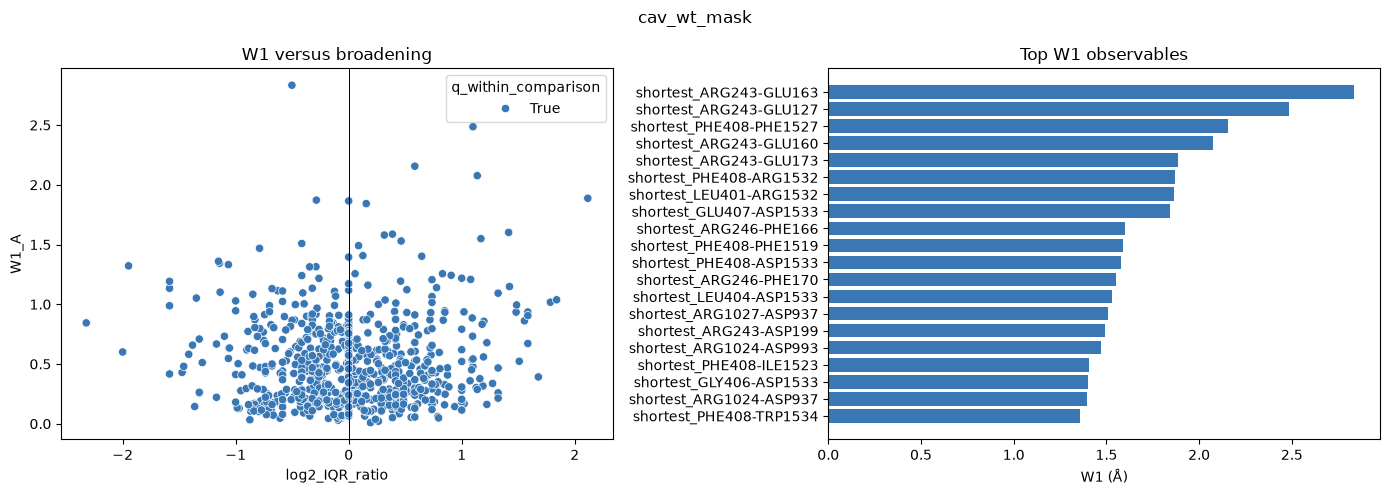

In [12]:
SELECTED_COMPARISON = primary.comparison_id.iloc[0]
selected_table = primary[primary.comparison_id.eq(SELECTED_COMPARISON)].copy()
selected_channel = comparison_registry.set_index('comparison_id').loc[SELECTED_COMPARISON, 'channel']
selected_colors = PROJECT_COLORS[selected_channel]
SELECTED_DISTANCE = selected_table.loc[selected_table.W1_A.idxmax(), 'distance']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=selected_table, x='log2_IQR_ratio', y='W1_A',
                hue=selected_table.q_within_comparison.lt(.05), palette={False:selected_colors['light'],True:selected_colors['dark']}, ax=axes[0])
axes[0].axvline(0,color='black',lw=.7); axes[0].set_title('W1 versus broadening')
top = selected_table.nlargest(min(20,len(selected_table)),'W1_A').sort_values('W1_A')
axes[1].barh(top.distance, top.W1_A, color=selected_colors['dark']); axes[1].set_title('Top W1 observables'); axes[1].set_xlabel('W1 (Å)')
fig.suptitle(SELECTED_COMPARISON); fig.tight_layout(); fig.savefig(figure_dir/f'{SELECTED_COMPARISON}_overview.png',dpi=180,bbox_inches='tight'); display(fig); plt.close(fig)

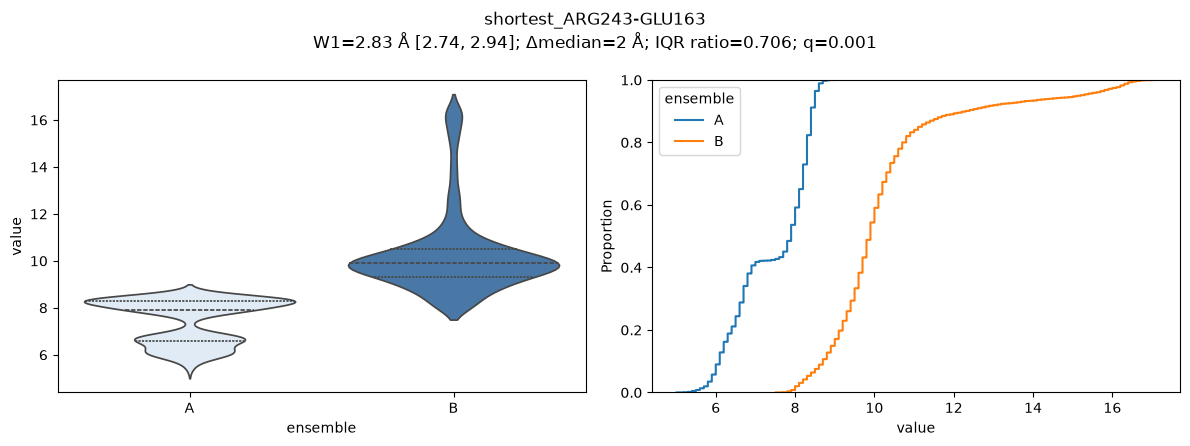

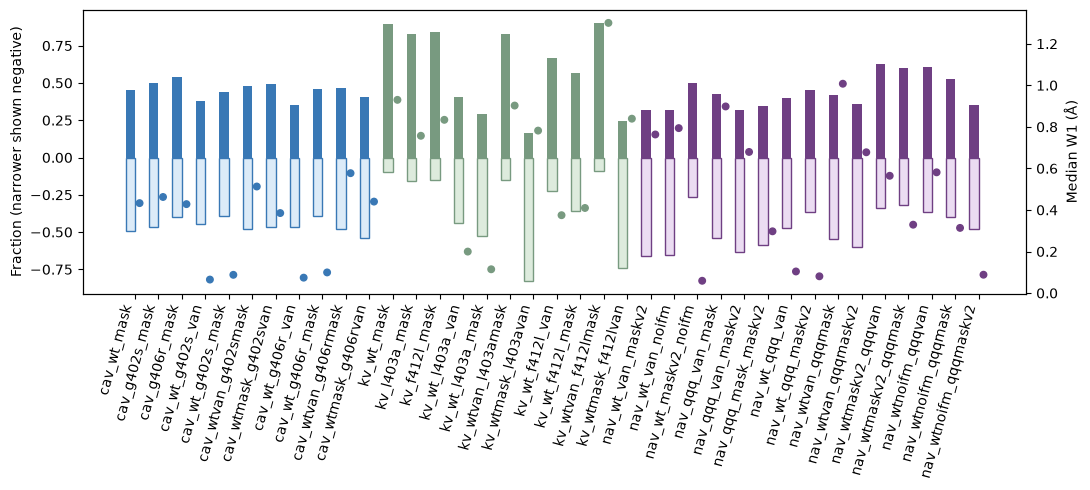

In [13]:
spec = comparison_registry.set_index('comparison_id').loc[SELECTED_COMPARISON]
detail_a = frames[f'{spec.channel}|{spec.condition_A}|{spec.protocol_A}']
detail_b = frames[f'{spec.channel}|{spec.condition_B}|{spec.protocol_B}']
detail_row = selected_table[selected_table.distance.eq(SELECTED_DISTANCE)].iloc[0]
plot_frame = pd.concat([
 pd.DataFrame({'value':pd.to_numeric(detail_a[SELECTED_DISTANCE],errors='coerce'),'ensemble':'A'}),
 pd.DataFrame({'value':pd.to_numeric(detail_b[SELECTED_DISTANCE],errors='coerce'),'ensemble':'B'})]).dropna()
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
sns.violinplot(data=plot_frame,x='ensemble',y='value',inner='quartile',cut=0,palette={'A':selected_colors['light'],'B':selected_colors['dark']},hue='ensemble',legend=False,ax=axes[0])
sns.ecdfplot(data=plot_frame,x='value',hue='ensemble',ax=axes[1])
fig.suptitle(f"{SELECTED_DISTANCE}\nW1={detail_row.W1_A:.3g} Å [{detail_row.W1_CI_low_A:.3g}, {detail_row.W1_CI_high_A:.3g}]; Δmedian={detail_row.delta_median_A:.3g} Å; IQR ratio={detail_row.IQR_ratio_B_over_A:.3g}; q={detail_row.q_within_comparison:.3g}")
fig.tight_layout(); fig.savefig(figure_dir/f'{SELECTED_COMPARISON}_detail.png',dpi=180,bbox_inches='tight'); display(fig); plt.close(fig)

fig, ax1 = plt.subplots(figsize=(11,5)); x=np.arange(len(comparison_summary))
summary_channels = comparison_summary.comparison_id.map(comparison_registry.set_index('comparison_id').channel)
light_colors = [PROJECT_COLORS[channel]['light'] for channel in summary_channels]
dark_colors = [PROJECT_COLORS[channel]['dark'] for channel in summary_channels]
ax1.bar(x-.2, comparison_summary.fraction_broader_B, .4, label='broader B', color=dark_colors)
ax1.bar(x-.2, -comparison_summary.fraction_narrower_B, .4, label='narrower B', color=light_colors, edgecolor=dark_colors)
ax2=ax1.twinx(); ax2.scatter(x+.2,comparison_summary.median_W1_A,c=dark_colors,label='median W1',s=22)
ax1.set_xticks(x,comparison_summary.comparison_id,rotation=75,ha='right'); ax1.set_ylabel('Fraction (narrower shown negative)'); ax2.set_ylabel('Median W1 (Å)')
fig.tight_layout(); fig.savefig(figure_dir/'comparison_summary.png',dpi=180,bbox_inches='tight'); display(fig); plt.close(fig)

## 10. WT–mutant protocol grid and similarity heatmaps

These panels address whether WT and mutant vanilla ensembles are numerically more similar than their masked counterparts. Like-for-like cells support mutation comparisons; off-diagonal cells are explicitly cross-protocol sensitivity analyses and must not be described as mutation-specific effects. Lower W1 means more similar distance distributions.

In [14]:
mutation_summary = comparison_summary.merge(
    comparison_registry[['comparison_id','channel','condition_B','protocol_A','protocol_B','comparison_class','notes']],
    on='comparison_id', how='left'
)
mutation_summary = mutation_summary[mutation_summary.comparison_class.str.startswith('mutation', na=False)].copy()
mutation_summary['channel_mutant'] = mutation_summary['channel'] + ' | ' + mutation_summary['condition_B']
display(mutation_summary.sort_values(['channel_mutant','protocol_A','protocol_B']))

same_protocol = mutation_summary[mutation_summary.protocol_A.eq(mutation_summary.protocol_B)].copy()
same_protocol['design'] = same_protocol['protocol_A']
similarity_test = same_protocol.pivot_table(index='channel_mutant', columns='design', values='median_W1_A', aggfunc='first')
similarity_test['masked_design'] = [
    'masked_v2' if name.startswith('nav15') else 'masked' for name in similarity_test.index
]
similarity_test['vanilla_W1_A'] = similarity_test.get('vanilla')
similarity_test['matched_mask_W1_A'] = [similarity_test.loc[name, design] for name, design in similarity_test.masked_design.items()]
similarity_test['masked_minus_vanilla_W1_A'] = similarity_test.matched_mask_W1_A - similarity_test.vanilla_W1_A
similarity_test['vanilla_more_similar'] = similarity_test.masked_minus_vanilla_W1_A > 0
similarity_test.reset_index().to_csv(output_root/'wt_mutant_vanilla_similarity_summary.csv', index=False)
display(similarity_test[['vanilla_W1_A','matched_mask_W1_A','masked_minus_vanilla_W1_A','vanilla_more_similar']])

,comparison_id,number_distances_tested,number_q_lt_0.05,fraction_q_lt_0.05,median_W1_A,median_normalized_W1,median_IQR_ratio,fraction_broader_B,fraction_narrower_B,maximum_W1_A,distance_with_maximum_W1,channel,condition_B,protocol_A,protocol_B,comparison_class,notes,channel_mutant
4,cav_wt_g402s_mask,660,569,0.862121,0.087811,0.119488,1.000000,0.436364,0.389394,1.589562,shortest_VAL400-MET1524,cav12,G402S,masked,masked,mutation,exact names only,cav12 | G402S
6,cav_wtmask_g402svan,660,660,1.000000,0.385035,0.564915,1.000000,0.492424,0.465152,2.818298,shortest_ARG243-GLU163,cav12,G402S,masked,vanilla,mutation_cross_protocol,non-equivalent protocols,cav12 | G402S
5,cav_wtvan_g402smask,660,660,1.000000,0.512789,0.639602,1.000000,0.478788,0.478788,2.668818,shortest_ARG243-GLU163,cav12,G402S,vanilla,masked,mutation_cross_protocol,non-equivalent protocols,cav12 | G402S
3,cav_wt_g402s_van,660,634,0.960606,0.064961,0.096436,1.000000,0.375758,0.448485,0.809560,shortest_LEU401-MET1524,cav12,G402S,vanilla,vanilla,mutation,exact names only,cav12 | G402S
8,cav_wt_g406r_mask,660,614,0.930303,0.099344,0.151566,1.000000,0.459091,0.395455,1.766296,shortest_PHE408-ARG1532,cav12,G406R,masked,masked,mutation,exact names only,cav12 | G406R
10,cav_wtmask_g406rvan,660,660,1.000000,0.440183,0.574796,0.951190,0.403030,0.542424,3.056602,shortest_PHE408-TRP1534,cav12,G406R,masked,vanilla,mutation_cross_protocol,non-equivalent protocols,cav12 | G406R
9,cav_wtvan_g406rmask,660,660,1.000000,0.577005,0.710220,1.000000,0.463636,0.480303,3.638096,shortest_PHE408-ARG1532,cav12,G406R,vanilla,masked,mutation_cross_protocol,non-equivalent protocols,cav12 | G406R
7,cav_wt_g406r_van,660,626,0.948485,0.074130,0.119123,1.000000,0.351515,0.465152,1.764700,shortest_PHE408-ARG1532,cav12,G406R,vanilla,vanilla,mutation,exact names only,cav12 | G406R
19,kv_wt_f412l_mask,1302,1298,0.996928,0.409483,0.146013,1.042822,0.566052,0.357143,1.672569,CA_CA_B_LYS429_CA-B_VAL184_CA,kv21,F412L,masked,masked,mutation,exact names only,kv21 | F412L
21,kv_wtmask_f412lvan,1302,1299,0.997696,0.839196,0.644619,0.500000,0.242704,0.741935,11.829004,shortest_LEU315A-LEU331B,kv21,F412L,masked,vanilla,mutation_cross_protocol,non-equivalent protocols,kv21 | F412L


design,vanilla_W1_A,matched_mask_W1_A,masked_minus_vanilla_W1_A,vanilla_more_similar
channel_mutant,,,,
cav12 | G402S,0.064961,0.087811,0.022850,True
cav12 | G406R,0.074130,0.099344,0.025214,True
kv21 | F412L,0.374741,0.409483,0.034742,True
kv21 | L403A,0.199632,0.114484,-0.085148,False
nav15 | QQQ,0.103959,0.080669,-0.023290,False


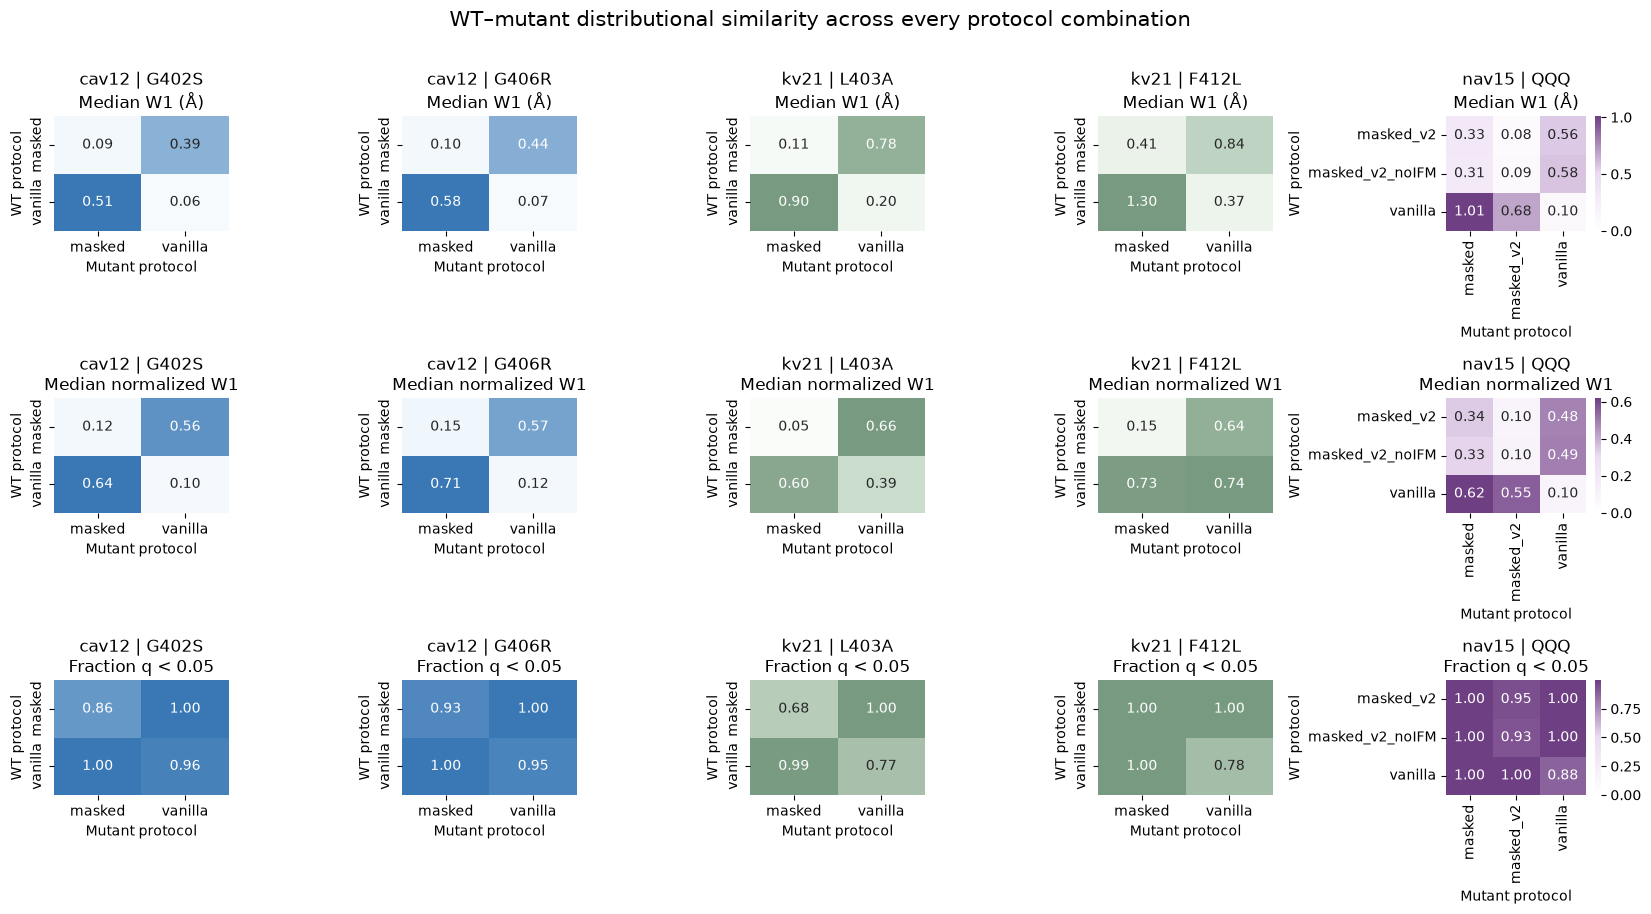

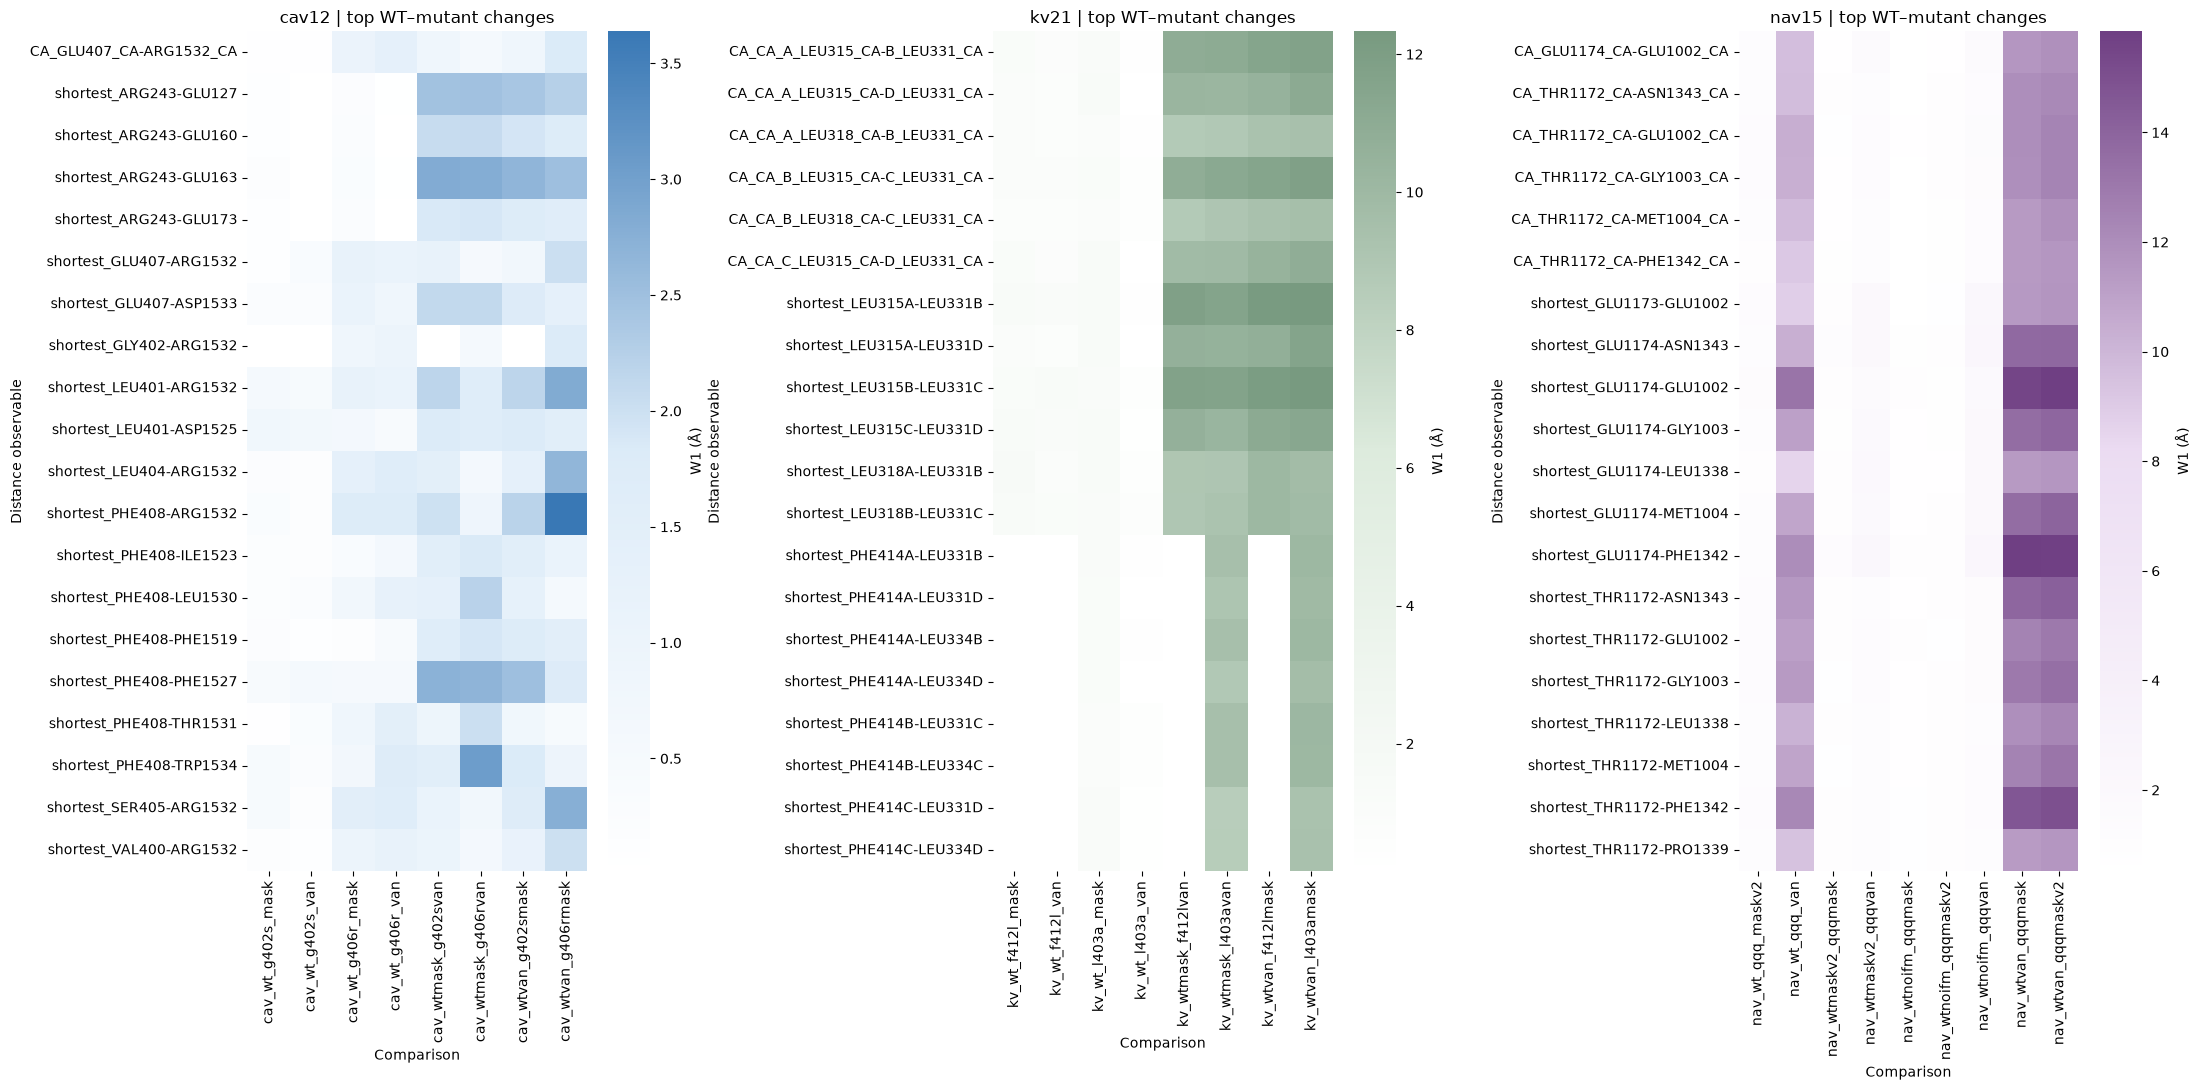

In [15]:
groups = list(mutation_summary.channel_mutant.drop_duplicates())
metrics = [('median_W1_A','Median W1 (Å)'), ('median_normalized_W1','Median normalized W1'), ('fraction_q_lt_0.05','Fraction q < 0.05')]
fig, axes = plt.subplots(len(metrics), len(groups), figsize=(3.3*len(groups), 9), squeeze=False)
for column_index, group_name in enumerate(groups):
    group = mutation_summary[mutation_summary.channel_mutant.eq(group_name)]
    for row_index, (metric, title) in enumerate(metrics):
        matrix = group.pivot(index='protocol_A', columns='protocol_B', values=metric)
        channel = group.channel.iloc[0]
        sns.heatmap(matrix, annot=True, fmt='.2f', cmap=PROJECT_CMAPS[channel],
                    vmin=0, cbar=column_index == len(groups)-1, ax=axes[row_index,column_index])
        axes[row_index,column_index].set_title(f'{group_name}\n{title}')
        axes[row_index,column_index].set_xlabel('Mutant protocol'); axes[row_index,column_index].set_ylabel('WT protocol')
fig.suptitle('WT–mutant distributional similarity across every protocol combination', y=1.01, fontsize=15)
fig.tight_layout(); fig.savefig(figure_dir/'wt_mutant_protocol_grid_heatmaps.png', dpi=200, bbox_inches='tight'); display(fig); plt.close(fig)

mutation_primary = primary[primary.comparison_id.isin(mutation_summary.comparison_id)].copy()
fig, axes = plt.subplots(1, 3, figsize=(22, 11), squeeze=False)
for ax, channel in zip(axes[0], ['cav12','kv21','nav15']):
    channel_data = mutation_primary[mutation_primary.channel.eq(channel)]
    top_distances = channel_data.groupby('distance').W1_A.max().nlargest(20).index
    distance_matrix = channel_data[channel_data.distance.isin(top_distances)].pivot_table(index='distance', columns='comparison_id', values='W1_A')
    sns.heatmap(distance_matrix, cmap=PROJECT_CMAPS[channel], ax=ax, cbar_kws={'label':'W1 (Å)'})
    ax.set_title(f'{channel} | top WT–mutant changes'); ax.set_xlabel('Comparison'); ax.set_ylabel('Distance observable')
fig.tight_layout(); fig.savefig(figure_dir/'wt_mutant_top_distance_heatmap.png', dpi=200, bbox_inches='tight'); display(fig); plt.close(fig)

## 11. Secondary interaction analysis

Difference-of-differences is intentionally secondary. It uses one median per matched trajectory and only like-for-like four-cell designs. The reusable primary layer above is complete; interaction designs should be activated only after confirming all four pairing audits for a channel/mask combination.

In [16]:
interaction_registry = pd.DataFrame([
 {'interaction_id':'cav_g402s_mask_interaction','channel':'cav12','wt_mask':'masked','mutant':'G402S','mutant_mask':'masked'},
 {'interaction_id':'cav_g406r_mask_interaction','channel':'cav12','wt_mask':'masked','mutant':'G406R','mutant_mask':'masked'},
 {'interaction_id':'kv_l403a_mask_interaction','channel':'kv21','wt_mask':'masked','mutant':'L403A','mutant_mask':'masked'},
 {'interaction_id':'kv_f412l_mask_interaction','channel':'kv21','wt_mask':'masked','mutant':'F412L','mutant_mask':'masked'},
 {'interaction_id':'nav_qqq_v2_mask_interaction','channel':'nav15','wt_mask':'masked_v2','mutant':'QQQ','mutant_mask':'masked_v2'},
])
display(interaction_registry)
print('Secondary registry recorded. Primary W1 outputs do not depend on interaction analysis.')

,interaction_id,channel,wt_mask,mutant,mutant_mask
0,cav_g402s_mask_interaction,cav12,masked,G402S,masked
1,cav_g406r_mask_interaction,cav12,masked,G406R,masked
2,kv_l403a_mask_interaction,kv21,masked,L403A,masked
3,kv_f412l_mask_interaction,kv21,masked,F412L,masked
4,nav_qqq_v2_mask_interaction,nav15,masked_v2,QQQ,masked_v2


Secondary registry recorded. Primary W1 outputs do not depend on interaction analysis.
